# Supervised learning - Classification
Goal of the excercise is to learn how to use Scikit-learn library for a classification tasks using Decision tree, SVM and NN. Moreover evaluate the performance of the proposed models.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

#### Data Dictionary

|Variable|Definition|Key|
|:-------|:-------|:--------|
|survival|Survival|0 = No, 1 = Yes|
|pclass|Ticket class|1 = 1st, 2 = 2nd, 3 = 3rd|
|sex|Sex||
|Age|Age in years||
|sibsp|# of siblings / spouses aboard the Titanic||
|parch|# of parents / children aboard the Titanic||
|ticket|Ticket number||
|fare|Passenger fare||
|cabin|Cabin number||
|embarked|Port of Embarkation|C = Cherbourg, Q = Queenstown, S = Southampton|

**pclass**: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

**age**: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp**: The dataset defines family relations in this way...
Sibling = brother, sister, stepbrother, stepsister
Spouse = husband, wife (mistresses and fiancés were ignored)

**parch**: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

- Decision tree https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- Train test split https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- Accuracy https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
- Metrics https://scikit-learn.org/stable/modules/model_evaluation.html
- K-Fold CV https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold
- SVM https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

## Load the titanic.csv dataset
- We want to create a model that predicts if a certain passanger survives or not, thus **survival** is the class label in this case

In [4]:
df = pd.read_csv('datasets/titanic.csv', index_col=0)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


## How many passangers survived?

In [5]:
df.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

## We need to pre-process the data first
- We want to use only numerical attributes as a model features
- Certain attributes need to be dropped and some of them can be encoded

### Which features would you drop and why?
### Which features could be encoded and which methods would you use?

In [6]:
df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

In [7]:
df.describe(exclude=np.number)

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [8]:
df.describe(include=np.number)

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## How many values are missing in the individual attributes?

In [9]:
df.isna().sum().sort_values(ascending=False)

Cabin       687
Age         177
Embarked      2
Survived      0
Pclass        0
Name          0
Sex           0
SibSp         0
Parch         0
Ticket        0
Fare          0
dtype: int64

## Let's drop Name and Ticket features - these have no use for us now

In [10]:
df = df.drop(['Name', 'Ticket'], axis=1)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,NaN,S
2,1,1,female,38.0,1,0,71.2833,C85,C
3,1,3,female,26.0,0,0,7.9250,NaN,S
4,1,1,female,35.0,1,0,53.1000,C123,S
5,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,NaN,S
888,1,1,female,19.0,0,0,30.0000,B42,S
889,0,3,female,NaN,1,2,23.4500,NaN,S


## Extract the deck identifier from the Cabin feature
- Note: A = top deck, G = lowest deck
- Change type to string
- Filter the first letter using *apply* function
- If the value is *nan* use *U* value as an replacement - this will mark the passangers with missing Cabin value
- Replace the T value with A

In [11]:
df.Cabin = df.Cabin.astype(str).apply(lambda x: x[0] if x != 'nan' else 'U').replace({'T': 'A'})

In [12]:
df.Cabin.value_counts()

Cabin
U    687
C     59
B     47
D     33
E     32
A     16
F     13
G      4
Name: count, dtype: int64

## The Age feature is tricky, we have multiple solutions for this, e.g.:
- Drop the feature
- Take the mean/median value to replace the missing value
- Take a random list of ages that maintains the original statistical summary values.
- Use a model to predict values based on the existing values.

### We will use the second option

<Axes: ylabel='Age'>

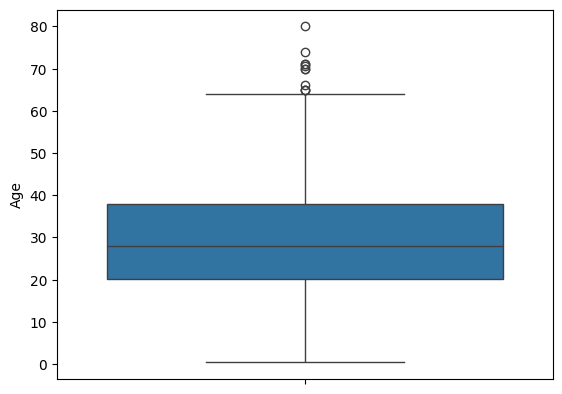

In [13]:
sns.boxplot(y=df.Age)

In [14]:
df.Age = df.Age.fillna(df.Age.mean())

<Axes: ylabel='Age'>

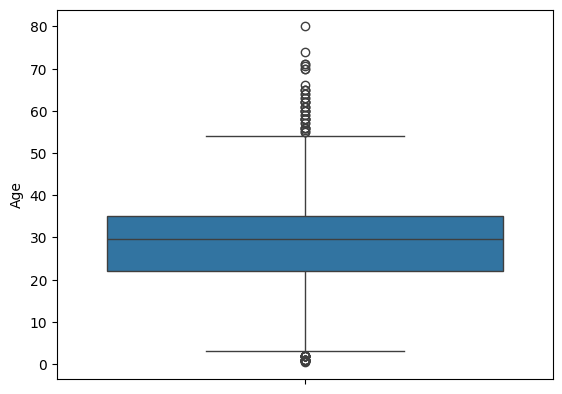

In [15]:
sns.boxplot(y=df.Age)

## Two passangers don't have the Embarked filled - we can drop these two rows

In [16]:
df = df.dropna().copy()

In [17]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.000000,1,0,7.2500,U,S
2,1,1,female,38.000000,1,0,71.2833,C,C
3,1,3,female,26.000000,0,0,7.9250,U,S
4,1,1,female,35.000000,1,0,53.1000,C,S
5,0,3,male,35.000000,0,0,8.0500,U,S
...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.000000,0,0,13.0000,U,S
888,1,1,female,19.000000,0,0,30.0000,B,S
889,0,3,female,29.699118,1,2,23.4500,U,S


## The last step of the pre-processing pipeline is to encode Sex, Cabin and Embarked features
- We will use one-hot encoding for Sex and Embarked and Ordinal encoding for Cabin
- Specify the encoding scheme for the ordinal encoding using an array in a form ['first', 'second', 'third', ...]

In [18]:
cabin_categories = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'U']
enc_cabin = OrdinalEncoder(categories=[cabin_categories])
enc_cabin.fit_transform(df[['Cabin']])[:, 0]

array([7., 2., 7., 2., 7., 7., 4., 7., 7., 7., 6., 2., 7., 7., 7., 7., 7.,
       7., 7., 7., 7., 3., 7., 0., 7., 7., 7., 2., 7., 7., 7., 1., 7., 7.,
       7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7.,
       7., 3., 7., 1., 2., 7., 7., 7., 7., 7., 2., 7., 7., 7., 5., 7., 7.,
       7., 7., 7., 7., 7., 7., 5., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7.,
       7., 7., 2., 7., 7., 7., 4., 7., 7., 7., 0., 3., 7., 7., 7., 7., 3.,
       7., 7., 7., 7., 7., 7., 7., 2., 7., 7., 7., 7., 7., 7., 7., 1., 7.,
       7., 7., 7., 4., 3., 7., 7., 7., 5., 7., 7., 7., 7., 7., 7., 7., 3.,
       2., 7., 1., 7., 7., 7., 7., 7., 7., 7., 7., 5., 7., 7., 2., 7., 7.,
       7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 4., 7., 7., 7., 1.,
       7., 7., 7., 0., 7., 7., 2., 7., 7., 7., 7., 7., 5., 7., 0., 7., 7.,
       7., 7., 7., 7., 7., 5., 1., 1., 7., 7., 7., 7., 7., 7., 7., 7., 7.,
       6., 7., 7., 7., 0., 7., 7., 7., 7., 7., 3., 7., 7., 3., 7., 7., 7.,
       7., 7., 2., 7., 7.

In [19]:
df['Cabin'] = enc_cabin.fit_transform(df[['Cabin']])[:, 0]

In [20]:
sex_categories = ['male', 'female']
enc_sex = OrdinalEncoder(categories=[sex_categories])
df['Sex'] = enc_sex.fit_transform(df[['Sex']])[:, 0]

In [21]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,0.0,22.0,1,0,7.2500,7.0,S
2,1,1,1.0,38.0,1,0,71.2833,2.0,C
3,1,3,1.0,26.0,0,0,7.9250,7.0,S
4,1,1,1.0,35.0,1,0,53.1000,2.0,S
5,0,3,0.0,35.0,0,0,8.0500,7.0,S


In [22]:
pd.get_dummies(df['Embarked'], prefix='Embarked')

,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,
1,False,False,True
2,True,False,False
3,False,False,True
4,False,False,True
5,False,False,True
...,...,...,...
887,False,False,True
888,False,False,True
889,False,False,True


In [23]:
df = pd.concat([df, pd.get_dummies(df['Embarked'], prefix='Embarked')], axis=1).drop('Embarked', axis=1)

## Now we have the data ready

In [24]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,0.0,22.000000,1,0,7.2500,7.0,False,False,True
2,1,1,1.0,38.000000,1,0,71.2833,2.0,True,False,False
3,1,3,1.0,26.000000,0,0,7.9250,7.0,False,False,True
4,1,1,1.0,35.000000,1,0,53.1000,2.0,False,False,True
5,0,3,0.0,35.000000,0,0,8.0500,7.0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,0.0,27.000000,0,0,13.0000,7.0,False,False,True
888,1,1,1.0,19.000000,0,0,30.0000,1.0,False,False,True
889,0,3,1.0,29.699118,1,2,23.4500,7.0,False,False,True


## Let's start with splitting the data into the input and output part
- Usually named as a *X* and *y* variables

In [25]:
X, y = df.loc[:, df.columns != 'Survived'], df.loc[:, 'Survived']

In [26]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,
1,3,0.0,22.0,1,0,7.2500,7.0,False,False,True
2,1,1.0,38.0,1,0,71.2833,2.0,True,False,False
3,3,1.0,26.0,0,0,7.9250,7.0,False,False,True
4,1,1.0,35.0,1,0,53.1000,2.0,False,False,True
5,3,0.0,35.0,0,0,8.0500,7.0,False,False,True


In [27]:
y.head()

PassengerId
1    0
2    1
3    1
4    1
5    0
Name: Survived, dtype: int64

## Lets continue with train test split process.
- Note that number of rows in the *X* and *y* in the Train/Test part of the data has to be equal

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((711, 10), (178, 10), (711,), (178,))

## Create the Decision tree classifier instance

In [29]:
clf = DecisionTreeClassifier()

### Use *fit()* method for training of classifier

In [30]:
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Lets use trained model for the prediction part
- Get predictions via the method *predict()*

In [31]:
y_pred = clf.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0])

### Can we evaluate our model?
- There are multiple metrics used: Accuracy, Recall, Precision, F1-Score, etc.
- Very useful is also creating a confusion matrix

### Take a look at this [article](https://builtin.com/data-science/precision-and-recall) and [wiki](https://en.wikipedia.org/wiki/Precision_and_recall) about precision and recall
- Beware the fact that as we increase precision, we decrease recall and vice-versa.

- **Precision** is the ratio of correctly predicted positive observations to the total predicted positive observations. The question that this metric answer is of all passengers that labeled as survived, how many actually survived? High precision relates to the low false positive rate.

- **Recall** is the ratio of correctly predicted positive observations to the all observations in actual class - yes. The question recall answers is: Of all the passengers that truly survived, how many did we label?

- **F1 Score** is the harmonic mean of Precision and Recall. Therefore, this score takes both false positives and false negatives into account. Intuitively it is not as easy to understand as accuracy, but F1 is usually more useful than accuracy, especially if you have an uneven class distribution. Accuracy works best if false positives and false negatives have similar cost. If the cost of false positives and false negatives are very different, it’s better to look at both Precision and Recall.

$ConfMatrix = \begin{bmatrix}
TP & FN\\
FP & TN
\end{bmatrix}$

In [32]:
accuracy_score(y_test, y_pred)

0.8146067415730337

## What does the confusion matrix tell us?
- Where do we find true positives, false positives etc?

<Axes: >

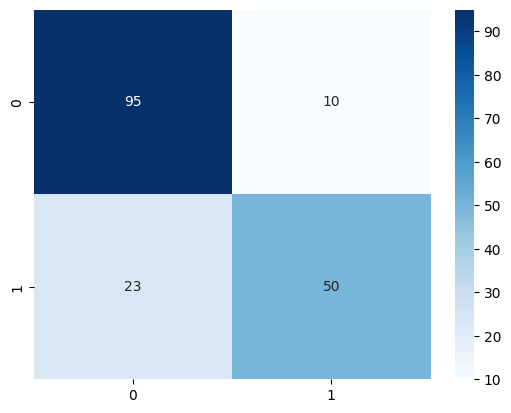

In [33]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")

In [34]:
confusion_matrix(y_test, y_pred)

array([[95, 10],
       [23, 50]])

In [35]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tn, fp, fn, tp

(np.int64(95), np.int64(10), np.int64(23), np.int64(50))

In [36]:
accuracy_score(y_test, y_pred)

0.8146067415730337

In [37]:
precision_score(y_test, y_pred)

0.8333333333333334

In [38]:
recall_score(y_test, y_pred)

0.684931506849315

In [39]:
f1_score(y_test, y_pred)

0.7518796992481203

## Can we improve our evaluation process?
- Lets try crossvalidation process for decision tree model
- https://scikit-learn.org/stable/modules/cross_validation.html
- **What is the difference between Pure and Stratified K-Fold?**

In [40]:
skf = KFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))
    print(f'Survival ratio in train set: {y_train.value_counts(normalize=True)[1]:.2}; Survival ratio in test set: {y_test.value_counts(normalize=True)[1]:.2}')
scores

Survival ratio in train set: 0.4; Survival ratio in test set: 0.33
Survival ratio in train set: 0.37; Survival ratio in test set: 0.44
Survival ratio in train set: 0.38; Survival ratio in test set: 0.39
Survival ratio in train set: 0.38; Survival ratio in test set: 0.4
Survival ratio in train set: 0.39; Survival ratio in test set: 0.35


[0.6614173228346457,
 0.7272727272727273,
 0.7391304347826086,
 0.6666666666666666,
 0.7751937984496124]

In [41]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))
    print(f'Survival ratio in train set: {y_train.value_counts(normalize=True)[1]:.2}; Survival ratio in test set: {y_test.value_counts(normalize=True)[1]:.2}')
    
scores

Survival ratio in train set: 0.38; Survival ratio in test set: 0.38
Survival ratio in train set: 0.38; Survival ratio in test set: 0.38
Survival ratio in train set: 0.38; Survival ratio in test set: 0.38
Survival ratio in train set: 0.38; Survival ratio in test set: 0.38
Survival ratio in train set: 0.38; Survival ratio in test set: 0.38


[0.6715328467153284,
 0.7194244604316546,
 0.7218045112781954,
 0.703125,
 0.7887323943661971]

In [42]:
np.mean(scores), np.min(scores), np.max(scores)

(np.float64(0.7209238425582751),
 np.float64(0.6715328467153284),
 np.float64(0.7887323943661971))

In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))
    
scores

[0.7361111111111112,
 0.6666666666666666,
 0.71875,
 0.7801418439716312,
 0.6818181818181818]

In [44]:
np.mean(scores), np.min(scores), np.max(scores)

(np.float64(0.7166975607135181),
 np.float64(0.6666666666666666),
 np.float64(0.7801418439716312))

## Other way to use crossvalidation in Sklearn

In [45]:
clf = DecisionTreeClassifier()
scores = cross_val_score(clf, X, y, cv=5, scoring='f1')
scores

array([0.67625899, 0.72463768, 0.73684211, 0.70769231, 0.8       ])

In [46]:
np.mean(scores), np.min(scores), np.max(scores)

(np.float64(0.7290862173841284),
 np.float64(0.6762589928057554),
 np.float64(0.8))

## Scale our data

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

In [48]:
clf = DecisionTreeClassifier()
scores = cross_val_score(clf, X_scaled, y, cv=5, scoring='f1')
scores

array([0.69565217, 0.72992701, 0.75555556, 0.68217054, 0.79432624])

In [49]:
np.mean(scores), np.min(scores), np.max(scores)

(np.float64(0.7315263041076558),
 np.float64(0.6821705426356589),
 np.float64(0.7943262411347518))

# Let's try other algorithms - SVM and ANN
- SVM - https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- SVM demo 1 - https://www.csie.ntu.edu.tw/~cjlin/libsvm/
- SVM demo 2 - https://cs.stanford.edu/~karpathy/svmjs/demo/
- SVM kernel trick https://towardsdatascience.com/optimization-loss-function-under-the-hood-part-iii-5dff33fa015d
- ANN - https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
- ANN demo - https://playground.tensorflow.org/

### Task 1: SVM (1b)
- Take a look at the parameters of the SVM, e.g. C, kernel, gamma (in case of RBF)
- **Try at least 5 different parameter's configurations**, use both linear and RBF kernel, you can also experiment with other
- **Does the preprocesing help with classifier perfromance?** Use both **X** and **X_scaled** for training and evaluating
- Tune the hyper-parameters and compare classification results after crossvalidation validation step
    - When using RBF kernel show a relation between parameters C and gamma. You can create table or heatmap similar to the one in the lecture.
    - **Write down to markdown cell which is better and why!**
- *Implementation note in Sklearn: SVC(kernel='linear') might be slow, u can use LinearSVC instead.*

In [57]:
scoring = "f1_macro"

In [58]:
def cv_mean_std(clf, X, y, cv, scoring):
    s = cross_val_score(clf, X, y, cv=cv, scoring=scoring)
    return s.mean(), s.min(), s.max()

scaling_comparision= []
# LINEAR
scaling_comparision.append(("SVC linear C=1  (X)",        *cv_mean_std(SVC(kernel="linear", C=1), X, y, skf, scoring)))
scaling_comparision.append(("SVC linear C=1  (X_scaled)", *cv_mean_std(SVC(kernel="linear", C=1), X_scaled, y, skf, scoring)))
# RBF
scaling_comparision.append(("SVC RBF C=1 γ=0.1  (X)",        *cv_mean_std(SVC(kernel="rbf", C=1, gamma=0.1), X, y, skf, scoring)))
scaling_comparision.append(("SVC RBF C=1 γ=0.1  (X_scaled)", *cv_mean_std(SVC(kernel="rbf", C=1, gamma=0.1), X_scaled, y, skf, scoring)))
# LinearSVC
scaling_comparision.append(("LinearSVC C=1  (X)",        *cv_mean_std(LinearSVC(C=1, dual=False), X, y, skf, scoring)))
scaling_comparision.append(("LinearSVC C=1  (X_scaled)", *cv_mean_std(LinearSVC(C=1, dual=False), X_scaled, y, skf, scoring)))

pd.DataFrame(scaling_comparision, columns=["model", f"mean {scoring}", "min", "max"]).sort_values(by=f"mean {scoring}", ascending=False)

,model,mean f1_macro,min,max
3,SVC RBF C=1 γ=0.1 (X_scaled),0.805436,0.785684,0.830361
4,LinearSVC C=1 (X),0.779315,0.748711,0.800476
5,LinearSVC C=1 (X_scaled),0.778026,0.742267,0.800476
0,SVC linear C=1 (X),0.769727,0.759199,0.786299
1,SVC linear C=1 (X_scaled),0.769727,0.759199,0.786299
2,SVC RBF C=1 γ=0.1 (X),0.664775,0.631150,0.715988


In [51]:
configs = {
    # LINEAR
    "linear_SVC_C0.1":  SVC(kernel="linear", C=0.1),
    "linear_SVC_C1":    SVC(kernel="linear", C=1),
    "linear_LSVC_C1":   LinearSVC(C=1, dual=False),

    # RBF 
    "rbf_C1_g1":        SVC(kernel="rbf", C=1, gamma=1),
    "rbf_C1_g0.1":      SVC(kernel="rbf", C=1, gamma=0.1),
    "rbf_C10_g0.1":     SVC(kernel="rbf", C=10, gamma=0.1),
    "rbf_C100_g0.01":   SVC(kernel="rbf", C=100, gamma=0.01),
}

rows = []
for name, clf in configs.items():
    scores = cross_val_score(clf, X_scaled, y, cv=skf, scoring=scoring)
    rows.append((name, scores.mean(), scores.min(), scores.max()))
pd.DataFrame(rows, columns=["config", f"mean {scoring}", "min", "max"]).sort_values(by=f"mean {scoring}", ascending=False)


,config,mean f1_macro,min,max
4,rbf_C1_g0.1,0.805436,0.785684,0.830361
6,rbf_C100_g0.01,0.803013,0.791132,0.813952
5,rbf_C10_g0.1,0.793985,0.781892,0.818244
2,linear_LSVC_C1,0.778026,0.742267,0.800476
3,rbf_C1_g1,0.774647,0.752778,0.807460
0,linear_SVC_C0.1,0.769727,0.759199,0.786299
1,linear_SVC_C1,0.769727,0.759199,0.786299


Best params: {'C': 10, 'gamma': 0.03}
Best CV score: 0.8104519266988083


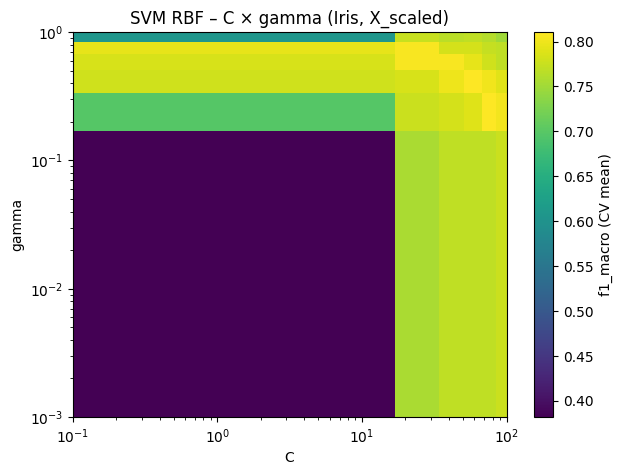

In [56]:
Cs = [0.1, 1, 3, 10, 30, 100]
Gammas = [0.001, 0.01, 0.03, 0.1, 0.3, 1.0]

gs = GridSearchCV(
    estimator=SVC(kernel="rbf"),
    param_grid={"C": Cs, "gamma": Gammas},
    cv=skf, scoring=scoring, n_jobs=-1
)
gs.fit(X_scaled, y)
print("Best params:", gs.best_params_)
print("Best CV score:", gs.best_score_)

scores_grid = np.zeros((len(Gammas), len(Cs)))
for i, g in enumerate(Gammas):
    for j, c in enumerate(Cs):
        s = cross_val_score(SVC(kernel="rbf", C=c, gamma=g), X_scaled, y, cv=skf, scoring=scoring)
        scores_grid[i, j] = s.mean()

plt.figure(figsize=(7,5))
im = plt.imshow(scores_grid, origin="lower", aspect="auto",
                extent=[min(Cs), max(Cs), min(Gammas), max(Gammas)])
plt.colorbar(im, label=f"{scoring} (CV mean)")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("C"); plt.ylabel("gamma")
plt.title("SVM RBF – C × gamma (Iris, X_scaled)")
plt.show()


Bylo otestováno několik konfigurací SVM s lineárním i RBF jádrem při různých hodnotách parametrů C a gamma. Nejlepšího výkonu dosáhl model **SVM s RBF jádrem (C=1, γ=0.1)** při použití škálovaných dat, kde průměrné F1 skóre dosáhlo **0.805**. Bez škálování měl tentýž model podstatně horší výsledek (pouze 0.66). Z toho vyplývá, že **preprocessing dat pomocí StandardScaleru výrazně zlepšuje výkon**, zejména u RBF jádra, protože sjednocuje měřítka vstupních atributů. Heatmapa navíc ukázala, že nejlepší výsledky jsou pro vyšší hodnoty C (10–100) a střední gamma (0.1–1). Celkově se tedy jako nejlepší konfigurace ukázal **SVM RBF s C=1, γ=0.1 a škálovanými daty**.


### Task 2: NN (1b)
- Take a look at the parameters of the MLPClassifier, e.g. hidden_layer_sizes, activation, solver, max_iter
- Tune the hyper-parameters and compare the ANN model proposed during the lecture
    - Choose the ideal form of presentation for hyperparameter tuning results (e.g. table with scores, plot showing the score relation to some parameter, etc.)
    - **Write down to markdown cell which is better and why!**

In [67]:
mlp_configs = {
    "mlp_10_relu_adam":      MLPClassifier(hidden_layer_sizes=(10,),    activation="relu", solver="adam",  max_iter=10000, random_state=42),
    "mlp_20_relu_adam":      MLPClassifier(hidden_layer_sizes=(20,),    activation="relu", solver="adam",  max_iter=10000, random_state=42),

    "mlp_10-5_relu_adam":    MLPClassifier(hidden_layer_sizes=(10, 5),  activation="relu", solver="adam",  max_iter=10000, random_state=42),
    "mlp_20-10_relu_lbfgs":  MLPClassifier(hidden_layer_sizes=(20, 10), activation="relu", solver="lbfgs", max_iter=10000, random_state=42),

    "mlp_10_tanh_adam":      MLPClassifier(hidden_layer_sizes=(10,),    activation="tanh", solver="adam",  max_iter=10000, random_state=42),

    "mlp_30_relu_sgd_lr0.01": MLPClassifier(hidden_layer_sizes=(30,),   activation="relu", solver="sgd",   learning_rate_init=0.01, max_iter=10000, random_state=42),
}

In [68]:
rows = []
for name, clf in mlp_configs.items():
    scores = cross_val_score(clf, X_scaled, y, cv=skf, scoring=scoring) 
    rows.append((name, scores.mean(), scores.min(), scores.max()))

pd.DataFrame(rows, columns=["config", f"mean {scoring}", "min", "max"]).sort_values(by=f"mean {scoring}", ascending=False)

,config,mean f1_macro,min,max
2,mlp_10-5_relu_adam,0.803121,0.772623,0.820492
0,mlp_10_relu_adam,0.800320,0.792354,0.813747
5,mlp_30_relu_sgd_lr0.01,0.797730,0.781653,0.812791
4,mlp_10_tanh_adam,0.790293,0.772623,0.823720
1,mlp_20_relu_adam,0.788498,0.783279,0.795402
3,mlp_20-10_relu_lbfgs,0.749521,0.711039,0.776556


Při trénování neuronové sítě bylo nutné zvýšit počet iterací na 10 000, protože modely se s výchozím limitem 1000 nestihly konvergovat. Nejlépe si vedla konfigurace **mlp_10-5_relu_adam** s průměrným F1 skóre 0.803, následovaná **mlp_10_relu_adam** (0.800). Obě využívají aktivační funkci ReLU a solver „adam“, který se ukázal jako nejspolehlivější. Větší sítě a solver „lbfgs“ dosahovaly horších výsledků, takže nejlepší výkon měly menší sítě s ReLU aktivací.


### Bonus task: OPTUNA (1b)
Use **Optuna** library for hyperparameter tuning process for one of previous classification methods (SVM, ANN).

A short list with some materials for this task:
- Hyperparameter tuning blog 1 https://medium.com/@iqra.bismi/hyper-parameter-tuning-of-machine-learning-models-using-optuna-f1905547937f
- Hyperparameter tuning blog 2 https://medium.com/@abdalrahman_shahrour/optuna-vs-gridsearch-57227556c450
- https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/005_visualization.html
- https://github.com/optuna/optuna
- https://github.com/optuna/optuna-dashboard and https://optuna.github.io/optuna-dashboard/

**What is the difference in using the Optuna instead of grid search?**

Hlavní rozdíl je v tom, že **Grid Search** zkouší všechny kombinace parametrů, což je přesné, ale velmi pomalé.
**Optuna** naopak používá chytré vyhledávání, které se z předchozích výsledků učí a vybírá jen slibné kombinace.
Díky tomu je **rychlejší a efektivnější**, zvlášť u většího počtu parametrů.


In [70]:
import optuna

/Users/dopeoff/Documents/skola/7. semestr/SU/machine_learning_course/m_l_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
def objective_svm(trial):
    C = trial.suggest_float("C", 0.01, 100, log=True)
    gamma = trial.suggest_float("gamma", 0.001, 1.0, log=True)

    clf = SVC(kernel="rbf", C=C, gamma=gamma)
    scores = cross_val_score(clf, X_scaled, y, cv=skf, scoring="f1_macro")
    return scores.mean()

study = optuna.create_study(direction="maximize", study_name="svm_rbf_iris")
study.optimize(objective_svm, n_trials=60, timeout=None, show_progress_bar=True)

print("Best value (CV f1_macro):", study.best_value)
print("Best params:", study.best_params)

[I 2025-11-04 16:20:38,390] A new study created in memory with name: svm_rbf_iris
Best trial: 0. Best value: 0.772714:   3%|▎         | 2/60 [00:00<00:08,  6.59it/s]

[I 2025-11-04 16:20:38,556] Trial 0 finished with value: 0.772714390905365 and parameters: {'C': 27.032526557119386, 'gamma': 0.4058827514130857}. Best is trial 0 with value: 0.772714390905365.
[I 2025-11-04 16:20:38,697] Trial 1 finished with value: 0.38177933177933177 and parameters: {'C': 0.01520528069971959, 'gamma': 0.001877953943262184}. Best is trial 0 with value: 0.772714390905365.


Best trial: 0. Best value: 0.772714:   7%|▋         | 4/60 [00:00<00:08,  6.73it/s]

[I 2025-11-04 16:20:38,876] Trial 2 finished with value: 0.38177933177933177 and parameters: {'C': 0.016847489102392102, 'gamma': 0.04722482141991725}. Best is trial 0 with value: 0.772714390905365.
[I 2025-11-04 16:20:39,004] Trial 3 finished with value: 0.7622507043674229 and parameters: {'C': 18.283399440912678, 'gamma': 0.9741659721691319}. Best is trial 0 with value: 0.772714390905365.


Best trial: 5. Best value: 0.772905:  10%|█         | 6/60 [00:00<00:08,  6.34it/s]

[I 2025-11-04 16:20:39,117] Trial 4 finished with value: 0.7684033588635114 and parameters: {'C': 33.439651843224546, 'gamma': 0.5190885078536337}. Best is trial 0 with value: 0.772714390905365.
[I 2025-11-04 16:20:39,311] Trial 5 finished with value: 0.7729053031623824 and parameters: {'C': 4.885990529367024, 'gamma': 0.0030775006373760486}. Best is trial 5 with value: 0.7729053031623824.


Best trial: 7. Best value: 0.783835:  13%|█▎        | 8/60 [00:01<00:07,  6.75it/s]

[I 2025-11-04 16:20:39,426] Trial 6 finished with value: 0.38177933177933177 and parameters: {'C': 0.0411781271122716, 'gamma': 0.003513357745916749}. Best is trial 5 with value: 0.7729053031623824.
[I 2025-11-04 16:20:39,624] Trial 7 finished with value: 0.7838345521871581 and parameters: {'C': 0.20526640058549717, 'gamma': 0.06069094110180384}. Best is trial 7 with value: 0.7838345521871581.


Best trial: 10. Best value: 0.788643:  17%|█▋        | 10/60 [00:01<00:06,  8.24it/s]

[I 2025-11-04 16:20:39,716] Trial 8 finished with value: 0.6271572074159162 and parameters: {'C': 0.40455381321516326, 'gamma': 0.00159686300343044}. Best is trial 7 with value: 0.7838345521871581.
[I 2025-11-04 16:20:39,803] Trial 9 finished with value: 0.7782177131310062 and parameters: {'C': 8.703360320016046, 'gamma': 0.005394361870513584}. Best is trial 7 with value: 0.7838345521871581.
[I 2025-11-04 16:20:39,893] Trial 10 finished with value: 0.7886431812302102 and parameters: {'C': 0.3262419422882461, 'gamma': 0.05884324729500538}. Best is trial 10 with value: 0.7886431812302102.


Best trial: 13. Best value: 0.790532:  23%|██▎       | 14/60 [00:01<00:04,  9.83it/s]

[I 2025-11-04 16:20:40,014] Trial 11 finished with value: 0.785185894066837 and parameters: {'C': 0.32467551316743665, 'gamma': 0.04959853607023885}. Best is trial 10 with value: 0.7886431812302102.
[I 2025-11-04 16:20:40,098] Trial 12 finished with value: 0.7832003790899206 and parameters: {'C': 1.828126823094163, 'gamma': 0.014086895614557822}. Best is trial 10 with value: 0.7886431812302102.
[I 2025-11-04 16:20:40,165] Trial 13 finished with value: 0.790531764839314 and parameters: {'C': 0.15571160140671786, 'gamma': 0.10586419954189323}. Best is trial 13 with value: 0.790531764839314.


Best trial: 17. Best value: 0.80679:  30%|███       | 18/60 [00:02<00:03, 12.16it/s] 

[I 2025-11-04 16:20:40,259] Trial 14 finished with value: 0.7943169417887861 and parameters: {'C': 0.1532700125996037, 'gamma': 0.15285071010194348}. Best is trial 14 with value: 0.7943169417887861.
[I 2025-11-04 16:20:40,341] Trial 15 finished with value: 0.773755393536699 and parameters: {'C': 0.06679092926568427, 'gamma': 0.1141416197158532}. Best is trial 14 with value: 0.7943169417887861.
[I 2025-11-04 16:20:40,406] Trial 16 finished with value: 0.8066602831723522 and parameters: {'C': 1.2927891056939973, 'gamma': 0.16401031377159656}. Best is trial 16 with value: 0.8066602831723522.
[I 2025-11-04 16:20:40,463] Trial 17 finished with value: 0.8067903688654287 and parameters: {'C': 1.2066559034597144, 'gamma': 0.1915256725549655}. Best is trial 17 with value: 0.8067903688654287.


Best trial: 17. Best value: 0.80679:  33%|███▎      | 20/60 [00:02<00:03, 11.98it/s]

[I 2025-11-04 16:20:40,514] Trial 18 finished with value: 0.7821327780925567 and parameters: {'C': 1.406430190984552, 'gamma': 0.015313965343936644}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:40,633] Trial 19 finished with value: 0.7772862758915713 and parameters: {'C': 76.49529785136463, 'gamma': 0.25566085867040783}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:40,689] Trial 20 finished with value: 0.7911360069077987 and parameters: {'C': 2.8511462249425805, 'gamma': 0.022026249733255388}. Best is trial 17 with value: 0.8067903688654287.


Best trial: 17. Best value: 0.80679:  40%|████      | 24/60 [00:02<00:02, 14.76it/s]

[I 2025-11-04 16:20:40,743] Trial 21 finished with value: 0.802576232877884 and parameters: {'C': 0.8925685079233098, 'gamma': 0.17782020927701275}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:40,793] Trial 22 finished with value: 0.8046023862487554 and parameters: {'C': 0.6994729919034117, 'gamma': 0.2358756600731417}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:40,850] Trial 23 finished with value: 0.8042746744546386 and parameters: {'C': 0.6421483530118044, 'gamma': 0.3657821993699779}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:40,915] Trial 24 finished with value: 0.7691308785877542 and parameters: {'C': 3.9098652742665227, 'gamma': 0.9674668638030783}. Best is trial 17 with value: 0.8067903688654287.


Best trial: 17. Best value: 0.80679:  47%|████▋     | 28/60 [00:02<00:02, 15.84it/s]

[I 2025-11-04 16:20:40,973] Trial 25 finished with value: 0.7828906191684851 and parameters: {'C': 8.49586572571021, 'gamma': 0.23726961121472182}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,020] Trial 26 finished with value: 0.8003730240381504 and parameters: {'C': 0.775362345802239, 'gamma': 0.09557181112063785}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,086] Trial 27 finished with value: 0.7772367570838787 and parameters: {'C': 1.4802502914034423, 'gamma': 0.5888130983767862}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,146] Trial 28 finished with value: 0.7811965906548294 and parameters: {'C': 0.08135427008548501, 'gamma': 0.2636311540003718}. Best is trial 17 with value: 0.8067903688654287.


Best trial: 17. Best value: 0.80679:  53%|█████▎    | 32/60 [00:02<00:01, 17.39it/s]

[I 2025-11-04 16:20:41,192] Trial 29 finished with value: 0.7955736449571001 and parameters: {'C': 2.7892463863451744, 'gamma': 0.030338189387245897}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,244] Trial 30 finished with value: 0.8059064435181009 and parameters: {'C': 0.5417842687378256, 'gamma': 0.3726743802479288}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,294] Trial 31 finished with value: 0.8061712527426822 and parameters: {'C': 0.5477685394496767, 'gamma': 0.41677224283129666}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,357] Trial 32 finished with value: 0.7973176807915924 and parameters: {'C': 0.47718237661145835, 'gamma': 0.47018724356234076}. Best is trial 17 with value: 0.8067903688654287.


Best trial: 17. Best value: 0.80679:  60%|██████    | 36/60 [00:03<00:01, 17.35it/s]

[I 2025-11-04 16:20:41,418] Trial 33 finished with value: 0.7839997389878158 and parameters: {'C': 1.3638415555820878, 'gamma': 0.641052112710487}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,471] Trial 34 finished with value: 0.8016946011108474 and parameters: {'C': 0.2611210671502737, 'gamma': 0.2964913705106547}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,529] Trial 35 finished with value: 0.7714654762251629 and parameters: {'C': 2.1735893124610466, 'gamma': 0.7017158608516757}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,581] Trial 36 finished with value: 0.7966105947652198 and parameters: {'C': 5.2445199598540455, 'gamma': 0.16486381920707813}. Best is trial 17 with value: 0.8067903688654287.


Best trial: 17. Best value: 0.80679:  67%|██████▋   | 40/60 [00:03<00:01, 18.04it/s]

[I 2025-11-04 16:20:41,634] Trial 37 finished with value: 0.780758290040698 and parameters: {'C': 0.10398497627861646, 'gamma': 0.0772187945563956}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,696] Trial 38 finished with value: 0.38177933177933177 and parameters: {'C': 0.024975219324053253, 'gamma': 0.45816488404781547}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,743] Trial 39 finished with value: 0.801201223514307 and parameters: {'C': 0.5031099065786979, 'gamma': 0.3548828829353353}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,800] Trial 40 finished with value: 0.7836379161204242 and parameters: {'C': 15.22438211671237, 'gamma': 0.13856907022068096}. Best is trial 17 with value: 0.8067903688654287.


Best trial: 42. Best value: 0.807054:  73%|███████▎  | 44/60 [00:03<00:00, 18.32it/s]

[I 2025-11-04 16:20:41,847] Trial 41 finished with value: 0.8055875053926564 and parameters: {'C': 0.990689150889822, 'gamma': 0.19723993396270398}. Best is trial 17 with value: 0.8067903688654287.
[I 2025-11-04 16:20:41,896] Trial 42 finished with value: 0.8070537271427604 and parameters: {'C': 1.0411153243427596, 'gamma': 0.1961254858716696}. Best is trial 42 with value: 0.8070537271427604.
[I 2025-11-04 16:20:41,957] Trial 43 finished with value: 0.7679639412110798 and parameters: {'C': 1.012240666148108, 'gamma': 0.0011287113556906318}. Best is trial 42 with value: 0.8070537271427604.
[I 2025-11-04 16:20:42,027] Trial 44 finished with value: 0.7785675730053981 and parameters: {'C': 0.21669885885334306, 'gamma': 0.8842479833808807}. Best is trial 42 with value: 0.8070537271427604.


Best trial: 48. Best value: 0.812271:  80%|████████  | 48/60 [00:03<00:00, 17.06it/s]

[I 2025-11-04 16:20:42,082] Trial 45 finished with value: 0.8011963403834187 and parameters: {'C': 0.35537083836441846, 'gamma': 0.37693153336465846}. Best is trial 42 with value: 0.8070537271427604.
[I 2025-11-04 16:20:42,134] Trial 46 finished with value: 0.7946839075627348 and parameters: {'C': 0.5073573086676796, 'gamma': 0.08743752108819881}. Best is trial 42 with value: 0.8070537271427604.
[I 2025-11-04 16:20:42,195] Trial 47 finished with value: 0.7991169228039658 and parameters: {'C': 6.459847657785317, 'gamma': 0.12666756254736403}. Best is trial 42 with value: 0.8070537271427604.
[I 2025-11-04 16:20:42,262] Trial 48 finished with value: 0.8122713708480592 and parameters: {'C': 3.1503035398018926, 'gamma': 0.07032803555242001}. Best is trial 48 with value: 0.8122713708480592.


Best trial: 48. Best value: 0.812271:  87%|████████▋ | 52/60 [00:04<00:00, 16.61it/s]

[I 2025-11-04 16:20:42,308] Trial 49 finished with value: 0.8019626584979168 and parameters: {'C': 3.506986106128338, 'gamma': 0.03836757028500095}. Best is trial 48 with value: 0.8122713708480592.
[I 2025-11-04 16:20:42,374] Trial 50 finished with value: 0.8025267191120659 and parameters: {'C': 14.142936582925632, 'gamma': 0.04550362642389602}. Best is trial 48 with value: 0.8122713708480592.
[I 2025-11-04 16:20:42,432] Trial 51 finished with value: 0.8031482413555089 and parameters: {'C': 1.8779469724071982, 'gamma': 0.19339952363140975}. Best is trial 48 with value: 0.8122713708480592.


Best trial: 48. Best value: 0.812271:  93%|█████████▎| 56/60 [00:04<00:00, 16.60it/s]

[I 2025-11-04 16:20:42,518] Trial 52 finished with value: 0.8001090313107826 and parameters: {'C': 1.1850768654020816, 'gamma': 0.06702668797059591}. Best is trial 48 with value: 0.8122713708480592.
[I 2025-11-04 16:20:42,597] Trial 53 finished with value: 0.7900881647957876 and parameters: {'C': 2.4681766469009614, 'gamma': 0.303802489435096}. Best is trial 48 with value: 0.8122713708480592.
[I 2025-11-04 16:20:42,645] Trial 54 finished with value: 0.799541431396038 and parameters: {'C': 0.6341567928609526, 'gamma': 0.11887619066510716}. Best is trial 48 with value: 0.8122713708480592.
[I 2025-11-04 16:20:42,698] Trial 55 finished with value: 0.7994976857550006 and parameters: {'C': 0.14861548560197996, 'gamma': 0.20140794714209698}. Best is trial 48 with value: 0.8122713708480592.


Best trial: 48. Best value: 0.812271: 100%|██████████| 60/60 [00:04<00:00, 13.36it/s]

[I 2025-11-04 16:20:42,745] Trial 56 finished with value: 0.7907501491323863 and parameters: {'C': 0.3206570425764625, 'gamma': 0.15052949848736938}. Best is trial 48 with value: 0.8122713708480592.
[I 2025-11-04 16:20:42,797] Trial 57 finished with value: 0.778045458857192 and parameters: {'C': 1.6955295434074307, 'gamma': 0.5098270378938572}. Best is trial 48 with value: 0.8122713708480592.
[I 2025-11-04 16:20:42,845] Trial 58 finished with value: 0.8121619579303099 and parameters: {'C': 3.835170326022926, 'gamma': 0.06250664447983158}. Best is trial 48 with value: 0.8122713708480592.
[I 2025-11-04 16:20:42,892] Trial 59 finished with value: 0.8052201070108149 and parameters: {'C': 3.9918199248555952, 'gamma': 0.02872484589901937}. Best is trial 48 with value: 0.8122713708480592.
Best value (CV f1_macro): 0.8122713708480592
Best params: {'C': 3.1503035398018926, 'gamma': 0.07032803555242001}


/var/folders/_r/b5yd1jqj5dg8_q46vf_wrsgr0000gn/T/ipykernel_56303/3837148636.py:7: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig1 = plot_optimization_history(study)
/var/folders/_r/b5yd1jqj5dg8_q46vf_wrsgr0000gn/T/ipykernel_56303/3837148636.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = plot_param_importances(study)
/var/folders/_r/b5yd1jqj5dg8_q46vf_wrsgr0000gn/T/ipykernel_56303/3837148636.py:9: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig3 = plot_contour(study, params=["C", "gamma"])


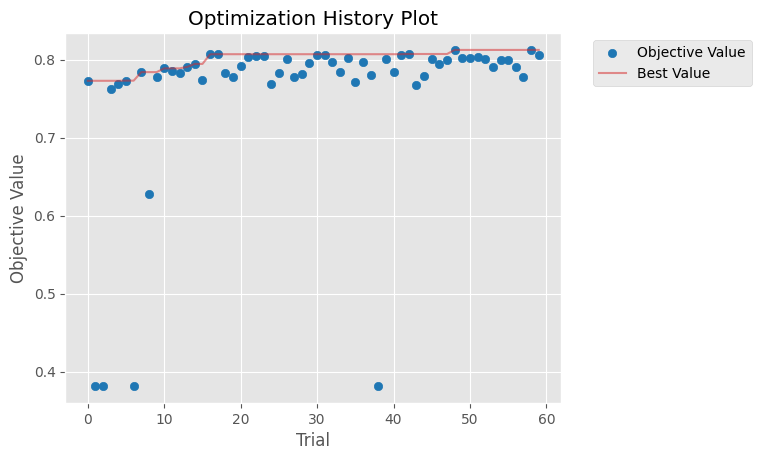

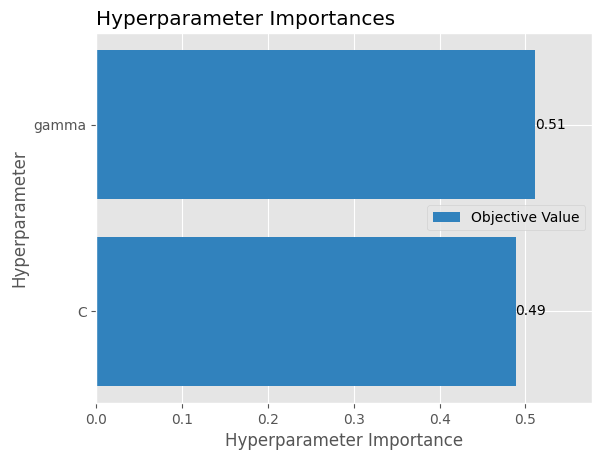

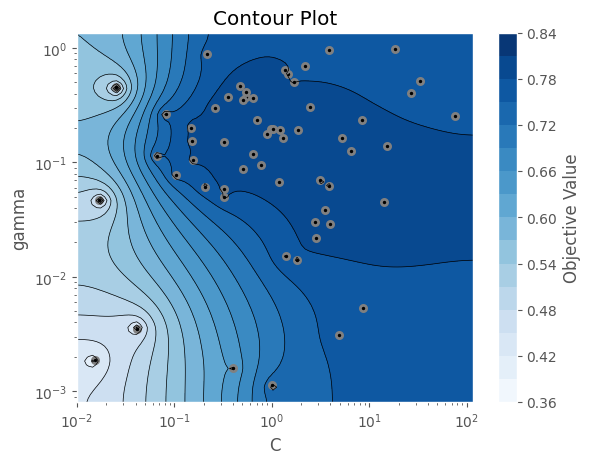

In [77]:
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_contour,
)

fig1 = plot_optimization_history(study)  
fig2 = plot_param_importances(study)
fig3 = plot_contour(study, params=["C", "gamma"])


In [ ]:
X_stand

,Fare,Age,SibSp,Parch,Pclass,Sex,Embarked_C,Embarked_Q,Embarked_S,Survived
PassengerId,,,,,,,,,,
1,-0.516380,-0.527669,0.522511,-0.506787,0.908600,1.0,False,False,True,0
2,0.694046,0.577094,0.522511,-0.506787,-1.482983,0.0,True,False,False,1
3,-0.503620,-0.251478,-0.552714,-0.506787,0.908600,0.0,False,False,True,1
4,0.350326,0.369951,0.522511,-0.506787,-1.482983,0.0,False,False,True,1
5,-0.501257,0.369951,-0.552714,-0.506787,0.908600,1.0,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...
886,-0.102875,0.646142,-0.552714,5.350885,0.908600,0.0,False,True,False,0
887,-0.407687,-0.182430,-0.552714,-0.506787,-0.287191,1.0,False,False,True,0
888,-0.086335,-0.734812,-0.552714,-0.506787,-1.482983,0.0,False,False,True,1
